# Doprinos 7 — Ispravljena simulacija streaming / real-time transkripcije

## Cilj eksperimenta

Cilj eksperimenta je analiza uticaja veličine audio segmenta (chunk-a) na performanse i tačnost Faster-Whisper sistema u simuliranim real-time uslovima.

Koristi se pet dugih prirodnih srpskih audio zapisa i Faster-Whisper `base` model sa `INT8` izvršavanjem na CPU-u. Analiziraju se chunk veličine od **2 s, 5 s i 10 s**, a rezultati se porede i sa transkripcijom kompletnog audio zapisa (`full-file baseline`).

Posmatraju se sledeće metrike:

* Word Error Rate (WER),
* ukupni Real-Time Factor (RTF),
* prosečna latencija obrade pojedinačnog chunk-a,
* Time To First Result (TTFR),
* queue delay,
* final tail delay.

Eksperiment predstavlja **kontrolisanu simulaciju streaming transkripcije nad unapred snimljenim audio zapisima**, a ne pravi live streamingiški nevalidnog poređenja.



In [1]:
import sys
!{sys.executable} -m pip install scipy

  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)


In [2]:
from pathlib import Path
import time
import wave
import re
import unicodedata
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import resample_poly
from faster_whisper import WhisperModel
from jiwer import wer

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)


In [3]:
# ============================================================
# PUTANJE
# ============================================================

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

AUDIO_DIR = PROJECT_ROOT / "audio" / "40Sentences00-08Notebooks"
REZULTATI_DIR = PROJECT_ROOT / "rezultati" / "07_streaming_chunking_real_time"

REZULTATI_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("AUDIO_DIR:", AUDIO_DIR)
print("REZULTATI_DIR:", REZULTATI_DIR)


PROJECT_ROOT: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR
AUDIO_DIR: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\audio\40Sentences00-08Notebooks
REZULTATI_DIR: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\07_streaming_chunking_real_time


In [4]:
REFERENCE = {36: 'Savremeni sistemi za automatsko prepoznavanje govora imaju veliki broj praktičnih primena. Mogu se koristiti za automatsko pravljenje transkripata sastanaka, generisanje titlova, glasovne asistente, pretragu multimedijalnog sadržaja i poboljšanje pristupačnosti digitalnih sistema. Ipak, kvalitet njihovog rada zavisi od velikog broja faktora. Govornici imaju različite glasove, akcente i brzine govora, dok snimci mogu nastati korišćenjem različitih mikrofona i u različitim prostorijama. Dodatni problem predstavlja pozadinski šum. Sistem koji veoma dobro radi u tihoj prostoriji ne mora da postigne isti rezultat na ulici ili u automobilu. Zbog toga evaluacija sistema ne bi trebalo da bude zasnovana na samo jednom zvučnom zapisu. Potrebno je koristiti više govornika, različite dužine snimaka i različite uslove. Pored tačnosti transkripcije, važno je analizirati vreme izvršavanja, potrošnju memorije i sposobnost sistema da obrađuje zvuk dovoljno brzo za praktičnu primenu.', 37: 'Kada govorimo o performansama modela za prepoznavanje govora, postoje dve različite stvari koje želimo da postignemo. Prva je što tačniji transkript, a druga što efikasnije izvršavanje. Veći model može bolje da prepozna komplikovane rečenice ili govor u težim uslovima, ali istovremeno može zahtevati mnogo više memorije i vremena. Manji model može biti nešto manje precizan, ali dovoljno brz da se koristi na običnom laptopu. Kvantizacija predstavlja još jedan način optimizacije jer omogućava korišćenje numeričkog formata manje preciznosti. Time se može smanjiti količina potrebne memorije i ubrzati obrada. Međutim, svaka optimizacija mora da bude eksperimentalno proverena. Nije dovoljno pokazati da je jedna konfiguracija brža. Potrebno je proveriti i da li je njena tačnost ostala prihvatljiva. Upravo zato se koriste metrike kao što su Word Error Rate, latencija i Real-Time Factor, koje omogućavaju da različite konfiguracije modela budu upoređene na objektivan način.', 38: 'Prošle nedelje imao sam prilično ispunjen dan. Ujutru sam ustao ranije jer sam morao da završim nekoliko obaveza pre odlaska u grad. Posle doručka proverio sam poruke, pripremio stvari koje su mi bile potrebne i krenuo automobilom. Na putu je bilo više saobraćaja nego što sam očekivao, pa mi je trebalo skoro pola sata da stignem do centra. Prvo sam otišao do prodavnice, zatim do banke, a nakon toga sam se našao sa prijateljem kojeg nisam video nekoliko meseci. Razgovarali smo o poslu, putovanjima i planovima za narednu godinu. Posle ručka vreme se iznenada promenilo i počela je jaka kiša. Sačekali smo nekoliko minuta da se vreme malo smiri, a onda smo krenuli kući. Kada sam se vratio, nastavio sam da radim na računaru. Uveče sam završio preostale obaveze i odlučio da ostatak dana provedem odmarajući se.', 39: 'Sistem koji obrađuje govor u realnom vremenu mora da rešava nešto drugačiji problem od sistema koji dobije kompletan audio zapis. Kod klasične transkripcije model može da dobije čitav snimak i zatim ga obradi. Kod realnog vremena zvuk neprestano pristiže, pa ga je potrebno podeliti na manje delove. Ako koristimo veoma kratke segmente, sistem može brzo da prikaže rezultat, ali model ima manje konteksta za pravilno prepoznavanje rečenice. Sa druge strane, ako koristimo duge segmente, model dobija više konteksta, ali korisnik mora duže da čeka na rezultat. Zbog toga izbor veličine segmenta predstavlja kompromis između latencije i kvaliteta transkripcije. Na primer, mogu se uporediti segmenti od dve, pet i deset sekundi. Za svaku konfiguraciju moguće je izmeriti vreme obrade, faktor realnog vremena i tačnost konačnog transkripta. Takav eksperiment omogućava da se utvrdi koja konfiguracija predstavlja najbolji kompromis za praktičan sistem.', 40: 'Cilj eksperimentalne analize sistema za automatsko prepoznavanje govora jeste da se utvrdi kako različiti faktori utiču na njegov rad. Možemo menjati veličinu modela, nivo pozadinskog šuma, jezik govornika, parametre dekodiranja, način kvantizacije ili korišćenje algoritma za detekciju govora. Svaki eksperiment treba organizovati tako da možemo jasno da utvrdimo posledice određene promene. Rezultati se zatim mogu posmatrati kroz više metrika. Word Error Rate pokazuje koliko se prepoznati tekst razlikuje od tačnog referentnog transkripta. Latencija pokazuje koliko vremena je potrebno za obradu, dok Real-Time Factor povezuje vreme obrade sa trajanjem samog zvučnog zapisa. Potrošnja memorije je posebno značajna kada model treba da radi na uređajima sa ograničenim resursima. Kombinovanjem ovih rezultata možemo da pronađemo konfiguraciju koja ne mora biti najbolja prema svakoj pojedinačnoj metrici, ali predstavlja dobar kompromis između tačnosti, brzine i potrebnih računarskih resursa.'}


In [5]:
# ============================================================
# TEST SET
# ============================================================

test_set = [
    {"broj": 36, "govornik": "govornik1", "audio": AUDIO_DIR / "36govornik1.wav", "referenca": REFERENCE[36]},
    {"broj": 37, "govornik": "govornik2", "audio": AUDIO_DIR / "37govornik2.wav", "referenca": REFERENCE[37]},
    {"broj": 38, "govornik": "govornik2", "audio": AUDIO_DIR / "38govornik2.wav", "referenca": REFERENCE[38]},
    {"broj": 39, "govornik": "govornik3", "audio": AUDIO_DIR / "39govornik3.wav", "referenca": REFERENCE[39]},
    {"broj": 40, "govornik": "govornik3", "audio": AUDIO_DIR / "40govornik3.wav", "referenca": REFERENCE[40]},
]

for item in test_set:
    if not item["audio"].exists():
        raise FileNotFoundError(f"Nije pronađen: {item['audio']}")

print(f"Pronađeno svih {len(test_set)} audio fajlova.")


Pronađeno svih 5 audio fajlova.


In [6]:
# ============================================================
# POMOĆNE FUNKCIJE
# ============================================================

WHISPER_SAMPLE_RATE = 16000

def ucitaj_wav_pcm16(putanja):
    with wave.open(str(putanja), "rb") as wf:
        sample_rate = wf.getframerate()
        broj_kanala = wf.getnchannels()
        sample_width = wf.getsampwidth()
        n_frames = wf.getnframes()
        audio_bytes = wf.readframes(n_frames)

    if sample_width != 2:
        raise ValueError(
            f"{putanja.name}: očekivan je 16-bit PCM WAV, "
            f"a dobijen sample_width={sample_width}."
        )

    audio = np.frombuffer(audio_bytes, dtype=np.int16).astype(np.float32) / 32768.0

    if broj_kanala > 1:
        audio = audio.reshape(-1, broj_kanala).mean(axis=1)

    return audio.astype(np.float32), sample_rate


def resampluj_na_16k(audio, original_sr):
    if original_sr == WHISPER_SAMPLE_RATE:
        return audio.astype(np.float32)

    g = math.gcd(int(original_sr), WHISPER_SAMPLE_RATE)
    up = WHISPER_SAMPLE_RATE // g
    down = int(original_sr) // g

    audio_16k = resample_poly(audio, up, down).astype(np.float32)
    return np.ascontiguousarray(audio_16k)


def normalizuj_tekst(text):
    text = unicodedata.normalize("NFKC", str(text)).lower()
    text = text.replace("–", " ").replace("—", " ")
    text = re.sub(r"[^\w\sčćžšđ]", " ", text, flags=re.UNICODE)
    text = re.sub(r"_", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def izracunaj_wer(referenca, transkript):
    ref = normalizuj_tekst(referenca)
    hyp = normalizuj_tekst(transkript)
    return wer(ref, hyp) * 100.0


def transkribuj_audio(model, audio_16k, language="sr"):
    if audio_16k.dtype != np.float32:
        audio_16k = audio_16k.astype(np.float32)

    audio_16k = np.ascontiguousarray(audio_16k)

    pocetak = time.perf_counter()

    segments, info = model.transcribe(
        audio_16k,
        language=language,
        beam_size=1,
        temperature=0.0,
        vad_filter=False,
        condition_on_previous_text=False
    )

    tekst = " ".join(
        segment.text.strip()
        for segment in segments
        if segment.text.strip()
    ).strip()

    vreme = time.perf_counter() - pocetak
    return tekst, vreme


## Metodološka ispravka — resampling na 16 kHz

Originalni audio zapisi imaju sample rate od **44,1 kHz**, dok Faster-Whisper pri direktnom prosleđivanju NumPy audio niza očekuje signal pripremljen na **16 kHz**.

Zbog toga se svi audio zapisi pre segmentacije eksplicitno resampluju sa 44,1 kHz na 16 kHz. Nakon resamplinga provereno je da je trajanje svih pet snimaka praktično potpuno očuvano, sa razlikama od samo **0,017 do 0,045 ms**.

Tek nakon resamplinga signal se deli na chunk-ove od 2, 5 i 10 sekundi. Na taj način svaki segment zaista predstavlja odgovarajuće trajanje audio sadržaja koji model očekuje.

Ova ispravka je neophodna jer bi direktno prosleđivanje 44,1 kHz NumPy signala kao 16 kHz promenilo efektivnu vremensku skalu audio zapisa i dovelo do metodološki nevalidnog poređenja.



In [7]:
# ============================================================
# UČITAVANJE + RESAMPLING + PROVERA
# ============================================================

audio_cache = {}
provera = []

for item in test_set:
    audio_original, original_sr = ucitaj_wav_pcm16(item["audio"])
    audio_16k = resampluj_na_16k(audio_original, original_sr)

    trajanje_original = len(audio_original) / original_sr
    trajanje_16k = len(audio_16k) / WHISPER_SAMPLE_RATE

    audio_cache[item["broj"]] = {
        "audio_16k": audio_16k,
        "original_sr": original_sr,
        "model_sr": WHISPER_SAMPLE_RATE,
        "trajanje": trajanje_16k
    }

    provera.append({
        "Broj": item["broj"],
        "Audio": item["audio"].name,
        "Govornik": item["govornik"],
        "Original SR [Hz]": original_sr,
        "Model SR [Hz]": WHISPER_SAMPLE_RATE,
        "Original trajanje [s]": round(trajanje_original, 3),
        "Trajanje posle resamplinga [s]": round(trajanje_16k, 3),
        "Razlika trajanja [ms]": round(abs(trajanje_original - trajanje_16k) * 1000, 3)
    })

tabela_provera = pd.DataFrame(provera)
display(tabela_provera)

if (tabela_provera["Razlika trajanja [ms]"] > 5).any():
    print("UPOZORENJE: proveri resampling — trajanje se promenilo više od očekivanog.")
else:
    print("OK: svi snimci su pravilno pripremljeni na 16 kHz uz očuvano trajanje.")


,Broj,Audio,Govornik,Original SR [Hz],Model SR [Hz],Original trajanje [s],Trajanje posle resamplinga [s],Razlika trajanja [ms]
0,36,36govornik1.wav,govornik1,44100,16000,69.010,69.010,0.045
1,37,37govornik2.wav,govornik2,44100,16000,82.431,82.431,0.036
2,38,38govornik2.wav,govornik2,44100,16000,64.459,64.459,0.031
3,39,39govornik3.wav,govornik3,44100,16000,62.613,62.613,0.017
4,40,40govornik3.wav,govornik3,44100,16000,79.772,79.772,0.033


OK: svi snimci su pravilno pripremljeni na 16 kHz uz očuvano trajanje.


In [8]:
# ============================================================
# MODEL
# ============================================================

MODEL_SIZE = "base"
DEVICE = "cpu"
COMPUTE_TYPE = "int8"
CHUNK_VELICINE = [2, 5, 10]

print(f"Učitavanje Faster-Whisper {MODEL_SIZE} {COMPUTE_TYPE.upper()} / {DEVICE.upper()}...")

model = WhisperModel(
    MODEL_SIZE,
    device=DEVICE,
    compute_type=COMPUTE_TYPE
)

print("Model je spreman.")

# Warm-up — ne ulazi u rezultate.
warmup_audio = audio_cache[36]["audio_16k"][:5 * WHISPER_SAMPLE_RATE]
_ = transkribuj_audio(model, warmup_audio)
print("Warm-up završen.")


Učitavanje Faster-Whisper base INT8 / CPU...
Model je spreman.
Warm-up završen.


## 1. Full-file baseline

Pre chunking eksperimenta svaki audio fajl se transkribuje kompletan. Ovo je kontrolna konfiguracija.

Ako je baseline WER i dalje neočekivano visok, notebook odmah prikazuje referencu i transkript, jer bi tada problem bio u samom audio sadržaju, referenci ili kvalitetu snimka — a ne u chunking logici.


In [9]:
# ============================================================
# FULL-FILE BASELINE
# ============================================================

baseline_rezultati = []

for indeks, item in enumerate(test_set, start=1):
    audio = audio_cache[item["broj"]]["audio_16k"]
    trajanje = audio_cache[item["broj"]]["trajanje"]

    print("\n" + "=" * 100)
    print(f"FULL FILE [{indeks}/5] — {item['audio'].name}")
    print("=" * 100)

    tekst, vreme = transkribuj_audio(model, audio)
    rtf = vreme / trajanje
    wer_proc = izracunaj_wer(item["referenca"], tekst)

    baseline_rezultati.append({
        "Broj": item["broj"],
        "Audio": item["audio"].name,
        "Govornik": item["govornik"],
        "Trajanje [s]": round(trajanje, 3),
        "Vreme obrade [s]": round(vreme, 3),
        "RTF": round(rtf, 4),
        "WER [%]": round(wer_proc, 2),
        "Referenca": item["referenca"],
        "Transkript": tekst
    })

    print(f"Trajanje={trajanje:.2f}s | obrada={vreme:.2f}s | RTF={rtf:.4f} | WER={wer_proc:.2f}%")
    print("TRANSKRIPT:")
    print(tekst)

df_baseline = pd.DataFrame(baseline_rezultati)

print("\nBASELINE REZIME")
display(df_baseline[["Broj", "Audio", "Trajanje [s]", "Vreme obrade [s]", "RTF", "WER [%]"]])



FULL FILE [1/5] — 36govornik1.wav
Trajanje=69.01s | obrada=5.01s | RTF=0.0726 | WER=53.08%
TRANSKRIPT:
Savrimini sistemi za otomacko prepoznavanja govara imaju velik broje praktičnih primena. Mogu se koristiti za otomacko pravnje transkripeta, sastanaka, generisanje titlova, glasov neasistente, pretrego multimelijalno-k sadrgeja i pobošanje pristoparšnosti digitanih sistema. Ipak kvalitet njihovo grada zavisio od velikog broje faktor. Gorenica i miro razećete glasove, akcente i brzi negovor. Dog snimci mogu nasati korišnje mračiti mikrofoni i u razećiti prostorijama. Dolatnim problem predstavlja pozdinskišum, sistem koji veoma dobro radi u tihvi prostoriji nemora da poscignijesti rezultat na ulici i utomu bilo. Zbog toga, evalulacije sistema ne bi trevalo da bude zastanoma na samo jednom zvušnom zapisu, potranune korisiti više govornika, različite tuži ne snima ka i različite uslove. Poretaršnosti, zreskripsije, važne analizirati vreme izvršavanja, potrošnju memoria i sposobno sistema

,Broj,Audio,Trajanje [s],Vreme obrade [s],RTF,WER [%]
0,36,36govornik1.wav,69.010,5.009,0.0726,53.08
1,37,37govornik2.wav,82.431,5.450,0.0661,34.75
2,38,38govornik2.wav,64.459,4.346,0.0674,34.31
3,39,39govornik3.wav,62.613,4.695,0.0750,47.48
4,40,40govornik3.wav,79.772,5.476,0.0686,45.52


In [10]:
# ============================================================
# DIJAGNOSTIKA BASELINE-a
# ============================================================

baseline_macro = df_baseline["WER [%]"].mean()

if baseline_macro > 100:
    print(
        "UPOZORENJE: prosečan full-file WER je i dalje >100%. "
        "To više nije problem sample-rate/chunking koda. "
        "Uporedi prikazane transkripte sa referencama i proveri da li audio 36–40 zaista sadrži ove tekstove."
    )
else:
    print(f"Baseline izgleda smisleno. Macro WER = {baseline_macro:.2f}%")


Baseline izgleda smisleno. Macro WER = 43.03%


## 2. Streaming/chunking simulacija

Svaki 16 kHz audio deli se na nezavisne segmente od 2, 5 i 10 sekundi.

Za real-time simulaciju koristi se događajni model reda čekanja:

- chunk postaje dostupan tek na kraju svog audio intervala (`arrival_time = chunk_end`);
- obrada može početi kada je chunk stigao i kada je prethodna obrada završena;
- `queue delay = processing_start - arrival_time`;
- `result delay = processing_finish - arrival_time`;
- za prvi chunk, procenjeni TTFR je vreme od početka snimanja do završetka obrade prvog chunk-a.

Na ovaj način TTFR nije samo inference vreme prvog chunk-a.


In [11]:
# ============================================================
# GLAVNI CHUNKING / STREAMING EKSPERIMENT
# ============================================================

rezultati_chunkovi = []
rezultati_fajlovi = []

for chunk_sec in CHUNK_VELICINE:

    print("\n" + "#" * 110)
    print(f"CHUNK SIZE = {chunk_sec} s")
    print("#" * 110)

    for indeks, item in enumerate(test_set, start=1):

        audio = audio_cache[item["broj"]]["audio_16k"]
        ukupno_trajanje = audio_cache[item["broj"]]["trajanje"]
        sr = WHISPER_SAMPLE_RATE

        chunk_samples = int(chunk_sec * sr)
        ukupno_uzoraka = len(audio)

        pozicija = 0
        chunk_id = 1

        transkripti = []
        vremena = []
        rtf_vrednosti = []
        result_delays = []
        queue_delays = []

        previous_finish = 0.0
        first_finish = None

        while pozicija < ukupno_uzoraka:
            kraj = min(pozicija + chunk_samples, ukupno_uzoraka)

            audio_chunk = audio[pozicija:kraj]
            trajanje_chunka = len(audio_chunk) / sr

            pocetak_audio = pozicija / sr
            kraj_audio = kraj / sr

            tekst, latency = transkribuj_audio(model, audio_chunk)
            rtf = latency / trajanje_chunka if trajanje_chunka > 0 else np.nan

            # Chunk može krenuti u obradu tek kada je kompletno "stigao".
            arrival_time = kraj_audio

            processing_start = max(arrival_time, previous_finish)
            queue_delay = processing_start - arrival_time
            processing_finish = processing_start + latency
            result_delay = processing_finish - arrival_time

            previous_finish = processing_finish

            if first_finish is None:
                first_finish = processing_finish

            rezultati_chunkovi.append({
                "Chunk size [s]": chunk_sec,
                "Broj": item["broj"],
                "Audio": item["audio"].name,
                "Govornik": item["govornik"],
                "Chunk ID": chunk_id,
                "Početak [s]": round(pocetak_audio, 3),
                "Kraj [s]": round(kraj_audio, 3),
                "Trajanje chunk-a [s]": round(trajanje_chunka, 3),
                "Inference latencija [s]": round(latency, 3),
                "RTF": round(rtf, 4),
                "RTF < 1": bool(rtf < 1.0),
                "Arrival time [s]": round(arrival_time, 3),
                "Processing start [s]": round(processing_start, 3),
                "Queue delay [s]": round(queue_delay, 3),
                "Processing finish [s]": round(processing_finish, 3),
                "Result delay od kraja chunk-a [s]": round(result_delay, 3),
                "Transkript chunk-a": tekst
            })

            transkripti.append(tekst)
            vremena.append(latency)
            rtf_vrednosti.append(rtf)
            result_delays.append(result_delay)
            queue_delays.append(queue_delay)

            print(
                f"chunk {chunk_id:02d} | audio={pocetak_audio:6.2f}-{kraj_audio:6.2f}s | "
                f"inference={latency:5.2f}s | RTF={rtf:5.3f} | "
                f"queue={queue_delay:5.2f}s | result_delay={result_delay:5.2f}s"
            )

            chunk_id += 1
            pozicija = kraj

        kompletan_transkript = " ".join(
            x for x in transkripti if x.strip()
        ).strip()

        wer_proc = izracunaj_wer(
            item["referenca"],
            kompletan_transkript
        )

        ukupno_vreme_obrade = float(sum(vremena))
        ukupni_rtf = ukupno_vreme_obrade / ukupno_trajanje

        prosecna_latency = float(np.mean(vremena))
        medijana_latency = float(np.median(vremena))
        p95_latency = float(np.percentile(vremena, 95))
        max_latency = float(np.max(vremena))

        procenat_real_time = float(
            np.mean(np.array(rtf_vrednosti) < 1.0) * 100
        )

        # Pravi procenjeni TTFR u ovoj simulaciji:
        # vreme do kraja prvog chunk-a + njegova obrada.
        estimated_ttfr = float(first_finish)

        max_queue_delay = float(max(queue_delays))
        max_result_delay = float(max(result_delays))

        # Na kraju audio toka, koliko sistem još kasni da isporuči poslednji rezultat.
        final_tail_delay = max(0.0, previous_finish - ukupno_trajanje)

        rezultati_fajlovi.append({
            "Chunk size [s]": chunk_sec,
            "Broj": item["broj"],
            "Audio": item["audio"].name,
            "Govornik": item["govornik"],
            "Trajanje audio [s]": round(ukupno_trajanje, 3),
            "Broj chunkova": len(vremena),
            "Ukupno vreme obrade [s]": round(ukupno_vreme_obrade, 3),
            "Ukupni RTF": round(ukupni_rtf, 4),
            "Prosečna latencija chunk-a [s]": round(prosecna_latency, 3),
            "Medijana latencije chunk-a [s]": round(medijana_latency, 3),
            "P95 latencija chunk-a [s]": round(p95_latency, 3),
            "Maksimalna latencija chunk-a [s]": round(max_latency, 3),
            "Estimated TTFR [s]": round(estimated_ttfr, 3),
            "Chunkovi sa RTF < 1 [%]": round(procenat_real_time, 2),
            "Maksimalni queue delay [s]": round(max_queue_delay, 3),
            "Maksimalni result delay [s]": round(max_result_delay, 3),
            "Final tail delay [s]": round(final_tail_delay, 3),
            "WER [%]": round(wer_proc, 2),
            "Referenca": item["referenca"],
            "Transkript": kompletan_transkript
        })

        print(
            f"\n=> FINAL: WER={wer_proc:.2f}% | total RTF={ukupni_rtf:.4f} | "
            f"Estimated TTFR={estimated_ttfr:.3f}s | "
            f"max queue={max_queue_delay:.3f}s | tail={final_tail_delay:.3f}s"
        )

df_chunkovi = pd.DataFrame(rezultati_chunkovi)
df_fajlovi = pd.DataFrame(rezultati_fajlovi)

print("\nStreaming/chunking eksperiment završen.")



##############################################################################################################
CHUNK SIZE = 2 s
##############################################################################################################
chunk 01 | audio=  0.00-  2.00s | inference= 0.86s | RTF=0.430 | queue= 0.00s | result_delay= 0.86s
chunk 02 | audio=  2.00-  4.00s | inference= 0.79s | RTF=0.397 | queue= 0.00s | result_delay= 0.79s
chunk 03 | audio=  4.00-  6.00s | inference= 0.80s | RTF=0.400 | queue= 0.00s | result_delay= 0.80s
chunk 04 | audio=  6.00-  8.00s | inference= 0.77s | RTF=0.385 | queue= 0.00s | result_delay= 0.77s
chunk 05 | audio=  8.00- 10.00s | inference= 0.77s | RTF=0.384 | queue= 0.00s | result_delay= 0.77s
chunk 06 | audio= 10.00- 12.00s | inference= 0.75s | RTF=0.377 | queue= 0.00s | result_delay= 0.75s
chunk 07 | audio= 12.00- 14.00s | inference= 0.75s | RTF=0.374 | queue= 0.00s | result_delay= 0.75s
chunk 08 | audio= 14.00- 16.00s | inference= 0.74s | RTF=0.3

In [12]:
# ============================================================
# REZIME PO CHUNK VELIČINI
# ============================================================

tabela_chunk_rezime = (
    df_fajlovi
    .groupby("Chunk size [s]")
    .agg(
        Broj_fajlova=("Audio", "count"),
        Prosecno_ukupno_vreme=("Ukupno vreme obrade [s]", "mean"),
        Prosecan_RTF=("Ukupni RTF", "mean"),
        Prosecna_chunk_latencija=("Prosečna latencija chunk-a [s]", "mean"),
        Prosecna_P95_latencija=("P95 latencija chunk-a [s]", "mean"),
        Prosecan_TTFR=("Estimated TTFR [s]", "mean"),
        Prosecan_max_queue=("Maksimalni queue delay [s]", "mean"),
        Prosecan_max_result_delay=("Maksimalni result delay [s]", "mean"),
        Prosecan_final_tail=("Final tail delay [s]", "mean"),
        Prosecan_WER=("WER [%]", "mean"),
        Medijana_WER=("WER [%]", "median"),
        Procenat_chunkova_real_time=("Chunkovi sa RTF < 1 [%]", "mean")
    )
    .reset_index()
    .round(3)
)

display(tabela_chunk_rezime)


,Chunk size [s],Broj_fajlova,Prosecno_ukupno_vreme,Prosecan_RTF,Prosecna_chunk_latencija,Prosecna_P95_latencija,Prosecan_TTFR,Prosecan_max_queue,Prosecan_max_result_delay,Prosecan_final_tail,Prosecan_WER,Medijana_WER,Procenat_chunkova_real_time
0,2,5,29.884,0.417,0.820,1.182,2.773,0.192,2.041,1.481,220.476,250.00,95.61
1,5,5,13.617,0.190,0.933,1.173,5.904,0.000,1.595,0.851,126.396,68.46,100.00
2,10,5,9.408,0.132,1.245,1.445,11.299,0.000,1.473,1.086,52.036,54.48,100.00


## Analiza rezultata

Full-file transkripcija korišćena je kao kontrolna konfiguracija. Prosečan WER za kompletne audio zapise iznosi **43,03%**, corpus WER **42,88%**, dok je prosečan RTF samo **0,0699**. To potvrđuje da model može obrađivati kompletne snimke znatno brže od njihovog realnog trajanja.

### Chunk od 2 sekunde

Chunk od 2 s omogućava najbrže prikazivanje prvog rezultata, sa prosečnim procenjenim TTFR-om od samo **2,773 s**. Međutim, ova konfiguracija ostvaruje veoma lošu tačnost:

* prosečan WER: **220,48%**,
* corpus WER: **221,88%**,
* prosečan RTF: **0,417**,
* prosečna chunk latencija: **0,820 s**.

U odnosu na full-file baseline, prosečan WER povećan je za čak **177,45 procentnih poena**.

Ovako visok WER pokazuje da segmenti od samo dve sekunde modelu ne pružaju dovoljno jezičkog i akustičkog konteksta. Nezavisno dekodiranje velikog broja veoma kratkih segmenata dodatno dovodi do fragmentisanih, ponovljenih i pogrešno prepoznatih delova teksta.

### Chunk od 5 sekundi

Povećanjem chunk-a na 5 s tačnost se poboljšava, ali je degradacija u odnosu na full-file transkripciju i dalje veoma velika:

* prosečan WER: **126,40%**,
* corpus WER: **126,43%**,
* prosečan RTF: **0,190**,
* prosečan TTFR: **5,904 s**.

U odnosu na 2 s chunk, prosečan WER je značajno smanjen, ali je i dalje za **83,37 procentnih poena** viši od full-file baseline-a.

Rezultati pojedinačnih snimaka dodatno pokazuju nestabilnost ove konfiguracije: WER za snimke 39 i 40 dostiže čak **228,06%** i **223,88%**.

### Chunk od 10 sekundi

Najbolju tačnost među testiranim streaming konfiguracijama ostvaruje chunk od 10 s:

* prosečan WER: **52,04%**,
* corpus WER: **51,98%**,
* prosečan RTF: **0,132**,
* prosečan TTFR: **11,299 s**.

Prosečan WER je samo **9,01 procentnih poena** viši od full-file baseline-a od 43,03%.

Na pojedinačnim snimcima WER penal u odnosu na full-file režim iznosi od samo **2,30 pp** za snimak 36 do **17,99 pp** za snimak 39.

Ovi rezultati pokazuju da povećanje chunk-a daje modelu više konteksta i značajno poboljšava kvalitet transkripcije. Istovremeno, cena tog poboljšanja je duže čekanje na prvi rezultat: TTFR raste sa **2,773 s** za 2 s chunk na ju, TTFR, red čekanja i kvalitet konačnog transkripta.


In [13]:
# ============================================================
# CORPUS WER
# ============================================================

corpus_rezultati = []

for chunk_sec in CHUNK_VELICINE:
    deo = df_fajlovi[
        df_fajlovi["Chunk size [s]"] == chunk_sec
    ].sort_values("Broj")

    ref_corpus = " ".join(
        normalizuj_tekst(x) for x in deo["Referenca"]
    )

    hyp_corpus = " ".join(
        normalizuj_tekst(x) for x in deo["Transkript"]
    )

    corpus_rezultati.append({
        "Chunk size [s]": chunk_sec,
        "Corpus WER [%]": round(wer(ref_corpus, hyp_corpus) * 100.0, 2)
    })

tabela_corpus = pd.DataFrame(corpus_rezultati)
display(tabela_corpus)


,Chunk size [s],Corpus WER [%]
0,2,221.88
1,5,126.43
2,10,51.98


In [14]:
# ============================================================
# BASELINE REZIME + FINALNO POREĐENJE
# ============================================================

baseline_macro_wer = df_baseline["WER [%]"].mean()
baseline_rtf = df_baseline["RTF"].mean()
baseline_vreme = df_baseline["Vreme obrade [s]"].mean()

baseline_ref_corpus = " ".join(
    normalizuj_tekst(x)
    for x in df_baseline.sort_values("Broj")["Referenca"]
)

baseline_hyp_corpus = " ".join(
    normalizuj_tekst(x)
    for x in df_baseline.sort_values("Broj")["Transkript"]
)

baseline_corpus_wer = wer(
    baseline_ref_corpus,
    baseline_hyp_corpus
) * 100.0

baseline_rezime = pd.DataFrame([{
    "Režim": "Full-file baseline",
    "Prosečno vreme [s]": round(baseline_vreme, 3),
    "Prosečan RTF": round(baseline_rtf, 4),
    "Prosečan WER [%]": round(baseline_macro_wer, 2),
    "Corpus WER [%]": round(baseline_corpus_wer, 2)
}])

display(baseline_rezime)

tabela_final = tabela_chunk_rezime.merge(
    tabela_corpus,
    on="Chunk size [s]",
    how="left"
)

tabela_final["Promena macro WER vs full-file [pp]"] = (
    tabela_final["Prosecan_WER"] - baseline_macro_wer
)

tabela_final["Promena corpus WER vs full-file [pp]"] = (
    tabela_final["Corpus WER [%]"] - baseline_corpus_wer
)

tabela_final = tabela_final.round(3)

print("ZAVRŠNO POREĐENJE")
display(tabela_final)


,Režim,Prosečno vreme [s],Prosečan RTF,Prosečan WER [%],Corpus WER [%]
0,Full-file baseline,4.995,0.0699,43.03,42.88


ZAVRŠNO POREĐENJE


,Chunk size [s],Broj_fajlova,Prosecno_ukupno_vreme,Prosecan_RTF,Prosecna_chunk_latencija,Prosecna_P95_latencija,Prosecan_TTFR,Prosecan_max_queue,Prosecan_max_result_delay,Prosecan_final_tail,Prosecan_WER,Medijana_WER,Procenat_chunkova_real_time,Corpus WER [%],Promena macro WER vs full-file [pp],Promena corpus WER vs full-file [pp]
0,2,5,29.884,0.417,0.820,1.182,2.773,0.192,2.041,1.481,220.476,250.00,95.61,221.88,177.448,179.002
1,5,5,13.617,0.190,0.933,1.173,5.904,0.000,1.595,0.851,126.396,68.46,100.00,126.43,83.368,83.552
2,10,5,9.408,0.132,1.245,1.445,11.299,0.000,1.473,1.086,52.036,54.48,100.00,51.98,9.008,9.102


In [15]:
# ============================================================
# DIREKTNO POREĐENJE SA FULL-FILE BASELINE-OM
# ============================================================

baseline_kratko = df_baseline[
    ["Broj", "WER [%]", "RTF", "Vreme obrade [s]"]
].rename(columns={
    "WER [%]": "Full-file WER [%]",
    "RTF": "Full-file RTF",
    "Vreme obrade [s]": "Full-file vreme [s]"
})

poredjenje_baseline = df_fajlovi.merge(
    baseline_kratko,
    on="Broj",
    how="left"
)

poredjenje_baseline["WER penal chunkovanja [pp]"] = (
    poredjenje_baseline["WER [%]"] -
    poredjenje_baseline["Full-file WER [%]"]
)

display(
    poredjenje_baseline[
        [
            "Chunk size [s]", "Broj", "Audio",
            "WER [%]", "Full-file WER [%]",
            "WER penal chunkovanja [pp]",
            "Ukupni RTF", "Full-file RTF",
            "Estimated TTFR [s]",
            "Maksimalni queue delay [s]",
            "Final tail delay [s]"
        ]
    ].round(3)
)


,Chunk size [s],Broj,Audio,WER [%],Full-file WER [%],WER penal chunkovanja [pp],Ukupni RTF,Full-file RTF,Estimated TTFR [s],Maksimalni queue delay [s],Final tail delay [s]
0,2,36,36govornik1.wav,81.54,53.08,28.46,0.393,0.073,2.860,0.000,0.764
1,2,37,37govornik2.wav,252.48,34.75,217.73,0.441,0.066,2.747,0.332,2.493
2,2,38,38govornik2.wav,275.91,34.31,241.60,0.436,0.067,2.743,0.285,2.510
3,2,39,39govornik3.wav,242.45,47.48,194.97,0.415,0.075,2.795,0.175,0.893
4,2,40,40govornik3.wav,250.00,45.52,204.48,0.400,0.069,2.719,0.168,0.746
5,5,36,36govornik1.wav,68.46,53.08,15.38,0.178,0.073,5.882,0.000,0.901
6,5,37,37govornik2.wav,53.19,34.75,18.44,0.178,0.066,5.840,0.000,0.747
7,5,38,38govornik2.wav,58.39,34.31,24.08,0.174,0.067,5.900,0.000,0.856
8,5,39,39govornik3.wav,228.06,47.48,180.58,0.214,0.075,5.943,0.000,0.842
9,5,40,40govornik3.wav,223.88,45.52,178.36,0.207,0.069,5.954,0.000,0.907


In [16]:
# ============================================================
# AUTOMATSKI SKOR ZA IZBOR CHUNK-A
# ============================================================

def score_lower_is_better(s):
    s = s.astype(float)
    mn, mx = s.min(), s.max()
    if np.isclose(mx, mn):
        return pd.Series(np.ones(len(s)), index=s.index)
    return (mx - s) / (mx - mn)

izbor = tabela_final.copy()

izbor["Skor_WER"] = score_lower_is_better(izbor["Prosecan_WER"])
izbor["Skor_RTF"] = score_lower_is_better(izbor["Prosecan_RTF"])
izbor["Skor_TTFR"] = score_lower_is_better(izbor["Prosecan_TTFR"])
izbor["Skor_queue"] = score_lower_is_better(izbor["Prosecan_max_queue"])

# Kompromis za streaming:
# 50% kvalitet, 20% RTF, 20% TTFR, 10% queue delay
izbor["Chunk_skor"] = (
    0.50 * izbor["Skor_WER"] +
    0.20 * izbor["Skor_RTF"] +
    0.20 * izbor["Skor_TTFR"] +
    0.10 * izbor["Skor_queue"]
)

izbor = izbor.sort_values("Chunk_skor", ascending=False).reset_index(drop=True)
izbor.insert(0, "Rang", np.arange(1, len(izbor) + 1))

display(
    izbor[
        [
            "Rang", "Chunk size [s]",
            "Prosecan_WER", "Corpus WER [%]",
            "Prosecan_RTF", "Prosecan_TTFR",
            "Prosecan_max_queue", "Chunk_skor"
        ]
    ].round(4)
)

najbolji_chunk = izbor.iloc[0]

print(
    f"Preporučeni chunk: {int(najbolji_chunk['Chunk size [s]'])} s | "
    f"skor={najbolji_chunk['Chunk_skor']:.4f}"
)


,Rang,Chunk size [s],Prosecan_WER,Corpus WER [%],Prosecan_RTF,Prosecan_TTFR,Prosecan_max_queue,Chunk_skor
0,1,10,52.036,51.98,0.132,11.299,0.000,0.8000
1,2,5,126.396,126.43,0.190,5.904,0.000,0.6651
2,3,2,220.476,221.88,0.417,2.773,0.192,0.2000


Preporučeni chunk: 10 s | skor=0.8000



## Analiza mogućnosti rada u realnom vremenu

Sve tri konfiguracije imaju prosečan ukupni RTF manji od 1, što znači da je prosečna brzina obrade dovoljna da prati dolazeći audio.

Kod chunk-ova od 5 i 10 s čak **100% chunk-ova** obrađeno je brže od njihovog trajanja, dok je kod 2 s konfiguracije taj procenat **95,61%**.

Ipak, kod 2 s konfiguracije pojavljuje se prosečan maksimalni queue delay od **0,192 s**, dok kod 5 i 10 s konfiguracija prosečan maksimalni queue delay iznosi **0 s**. To pokazuje da veoma kratki chunk-ovi mogu povremeno da se obrađuju sporije nego što novi audio segmenti pristižu.

Zato mali RTF sam po sebi nije dovoljan za procenu praktičnog streaming sistema. Potrebno je istovremeno posmatrati latenciju, TTFR, red čekanja i kvalitet konačnog transkripta.


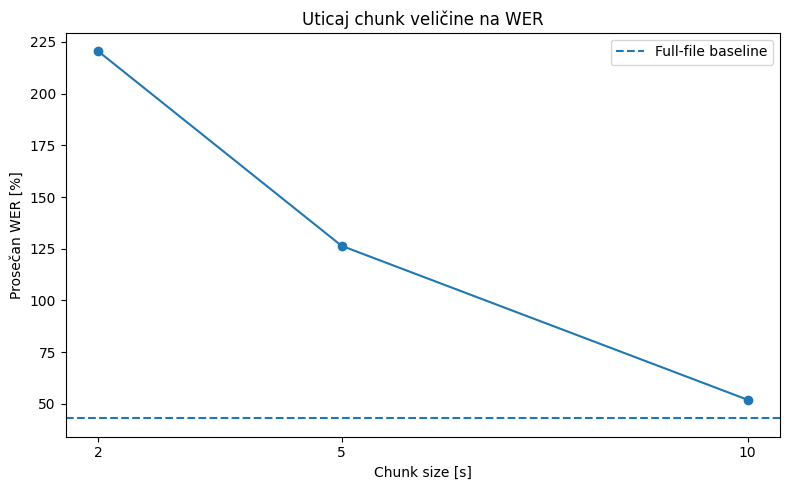

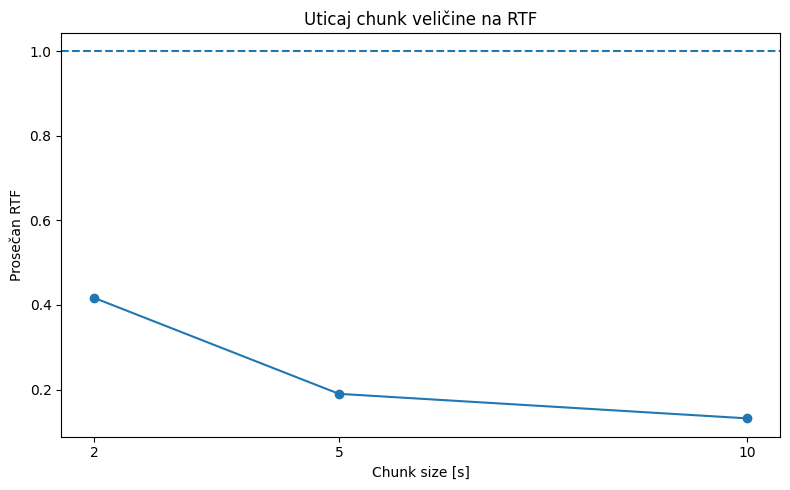

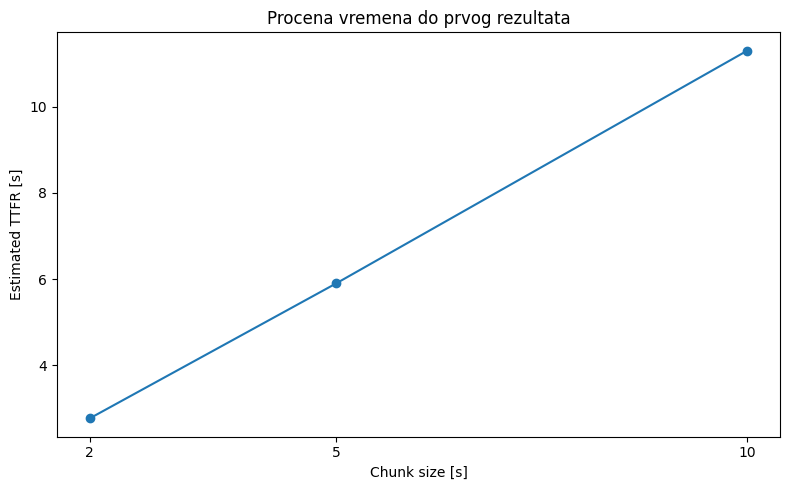

In [17]:
# ============================================================
# GRAFICI
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(tabela_final["Chunk size [s]"], tabela_final["Prosecan_WER"], marker="o")
plt.axhline(baseline_macro_wer, linestyle="--", label="Full-file baseline")
plt.xlabel("Chunk size [s]")
plt.ylabel("Prosečan WER [%]")
plt.title("Uticaj chunk veličine na WER")
plt.xticks(CHUNK_VELICINE)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(tabela_final["Chunk size [s]"], tabela_final["Prosecan_RTF"], marker="o")
plt.axhline(1.0, linestyle="--")
plt.xlabel("Chunk size [s]")
plt.ylabel("Prosečan RTF")
plt.title("Uticaj chunk veličine na RTF")
plt.xticks(CHUNK_VELICINE)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(tabela_final["Chunk size [s]"], tabela_final["Prosecan_TTFR"], marker="o")
plt.xlabel("Chunk size [s]")
plt.ylabel("Estimated TTFR [s]")
plt.title("Procena vremena do prvog rezultata")
plt.xticks(CHUNK_VELICINE)
plt.tight_layout()
plt.show()


In [18]:
# ============================================================
# ČUVANJE REZULTATA
# ============================================================

tabela_provera.to_csv(
    REZULTATI_DIR / "07_audio_provera.csv",
    index=False,
    encoding="utf-8-sig"
)

df_baseline.to_csv(
    REZULTATI_DIR / "07_full_file_baseline.csv",
    index=False,
    encoding="utf-8-sig"
)

df_chunkovi.to_csv(
    REZULTATI_DIR / "07_svi_chunk_rezultati.csv",
    index=False,
    encoding="utf-8-sig"
)

df_fajlovi.to_csv(
    REZULTATI_DIR / "07_rezultati_po_fajlu.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_corpus.to_csv(
    REZULTATI_DIR / "07_corpus_wer.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_final.to_csv(
    REZULTATI_DIR / "07_chunking_finalni_rezime.csv",
    index=False,
    encoding="utf-8-sig"
)

poredjenje_baseline.to_csv(
    REZULTATI_DIR / "07_chunk_vs_full_file.csv",
    index=False,
    encoding="utf-8-sig"
)

izbor.to_csv(
    REZULTATI_DIR / "07_chunk_preporuka.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Rezultati sačuvani u:")
print(REZULTATI_DIR)


Rezultati sačuvani u:
D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\07_streaming_chunking_real_time


## Zaključak eksperimenta

Eksperiment pokazuje jasan kompromis između **brzine dobijanja prvog rezultata i tačnosti transkripcije**.

Chunk od **2 s** omogućava najmanji prosečan TTFR od **2,773 s**, ali zbog nedostatka konteksta ostvaruje veoma visok prosečan WER od **220,48%**. Povećanjem chunk-a na **5 s** WER se smanjuje na **126,40%**, dok TTFR raste na **5,904 s**.

Najbolju tačnost među analiziranim streaming konfiguracijama ostvaruje **10 s chunk**, sa prosečnim WER-om od **52,04%** i corpus WER-om od **51,98%**. To je relativno blizu full-file baseline-u od **43,03% macro WER-a** i **42,88% corpus WER-a**, ali prosečan TTFR raste na **11,299 s**.

Istovremeno, 10 s konfiguracija ima prosečan RTF od samo **0,132**, a svih 100% analiziranih chunk-ova obrađeno je brže od njihovog trajanja, bez prosečnog nagomilavanja reda čekanja.

Rezultati zato pokazuju da u korišćenoj konfiguraciji veoma kratki nezavisni chunk-ovi nisu pogodni za kvalitetnu transkripciju. Duži segmenti pružaju modelu više konteksta i značajno smanjuju WER, ali povećavaju vreme potrebno do prvog rezultata.

Od testiranih veličina, **10 s predstavlja konfiguraciju sa najmanjim WER-om**, dok **2 s pruža najkraći TTFR**. Izbor veličine chunk-a zato predstavlja direktan kompromis između odziva sistema i kvaliteta transkripcije.

Važno je naglasiti da ovaj eksperiment predstavlja simulaciju u kojoj se svaki chunk transkribuje nezavisno, bez preklapanja susednih segmenata i bez složenijih mehanizama za očuvanje konteksta. Zbog toga rezultati ne predstavljaju gornju granicu kvaliteta pravog streaming ASR sistema, već pokazuju ograničenja jednostavnog chunking pristupa.
